# Session 3

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import sklearn
import imblearn
from sklearn import preprocessing, neighbors, inspection
from sklearn.model_selection import train_test_split

### Distanzberechnung

In [2]:
pointA = [1,2,3]
pointB = [3,2,1]
pointC = [4,7,1]

In [3]:
# Einfache Distanzberechnung:
scipy.spatial.distance.pdist([pointA, pointB], metric="minkowski", p=2)

array([2.82842712])

In [4]:
# Manueller Check
sum([(x1 - x2)**2 for x1, x2 in zip(pointA, pointB)])**(1/2)

2.8284271247461903

In [5]:
# Matrix an Distanzen
scipy.spatial.distance.squareform(scipy.spatial.distance.pdist([pointA, pointB, pointC], metric="minkowski", p=2))

array([[0.        , 2.82842712, 6.164414  ],
       [2.82842712, 0.        , 5.09901951],
       [6.164414  , 5.09901951, 0.        ]])

In [6]:
# Distanzberechnung zwischen zwei Listen an Distanzen
scipy.spatial.distance.cdist([pointA, pointB], [pointB, pointC, pointA], metric="minkowski", p=2)

array([[2.82842712, 6.164414  , 0.        ],
       [0.        , 5.09901951, 2.82842712]])

### Skalierung

In [7]:
iris_data = pd.read_csv("iris.csv").drop("Id", axis=1)
iris_data

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


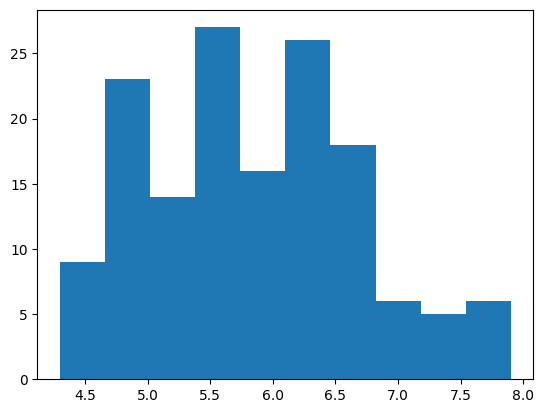

In [8]:
original_data = iris_data[["SepalLengthCm"]]
plt.hist(original_data)
plt.show()

In [9]:
original_data.describe()

,SepalLengthCm
count,150.000000
mean,5.843333
std,0.828066
min,4.300000
25%,5.100000
50%,5.800000
75%,6.400000
max,7.900000


#### MinMax Skalierung


In [10]:
(original_data - original_data.min()) / (original_data.max() - original_data.min())

,SepalLengthCm
0,0.222222
1,0.166667
2,0.111111
3,0.083333
4,0.194444
...,...
145,0.666667
146,0.555556
147,0.611111
148,0.527778


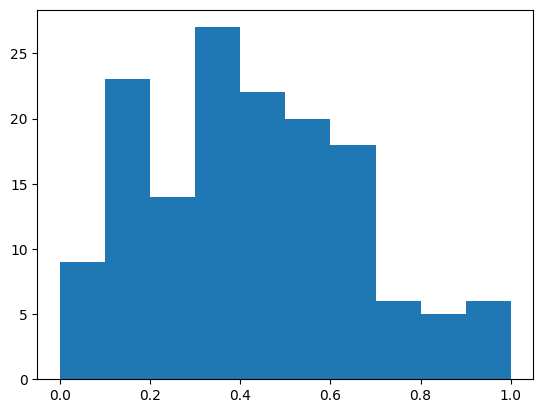

In [11]:
minmax_scaler = sklearn.preprocessing.MinMaxScaler()
scaled_data = minmax_scaler.fit_transform(original_data)
plt.hist(scaled_data)
plt.show()

In [12]:
pd.DataFrame(scaled_data).describe()

,0
count,150.000000
mean,0.428704
std,0.230018
min,0.000000
25%,0.222222
50%,0.416667
75%,0.583333
max,1.000000


#### Standardisierung

In [13]:
# Manueller Weg
(original_data - original_data.mean()) / original_data.std()

,SepalLengthCm
0,-0.897674
1,-1.139200
2,-1.380727
3,-1.501490
4,-1.018437
...,...
145,1.034539
146,0.551486
147,0.793012
148,0.430722


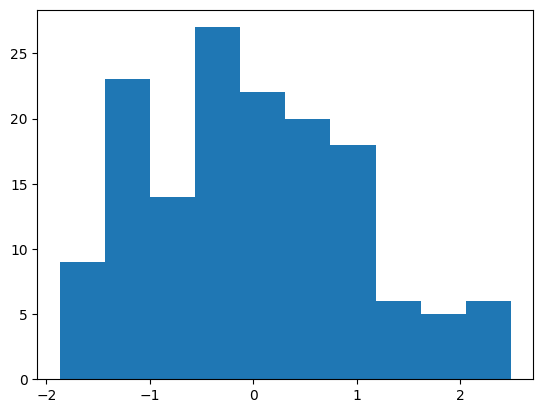

In [14]:
standard_scaler = sklearn.preprocessing.StandardScaler()
standard_data = standard_scaler.fit_transform(original_data)
plt.hist(standard_data)
plt.show()

In [15]:
pd.DataFrame(standard_data).describe()

,0
count,1.500000e+02
mean,-4.736952e-16
std,1.003350e+00
min,-1.870024e+00
25%,-9.006812e-01
50%,-5.250608e-02
75%,6.745011e-01
max,2.492019e+00


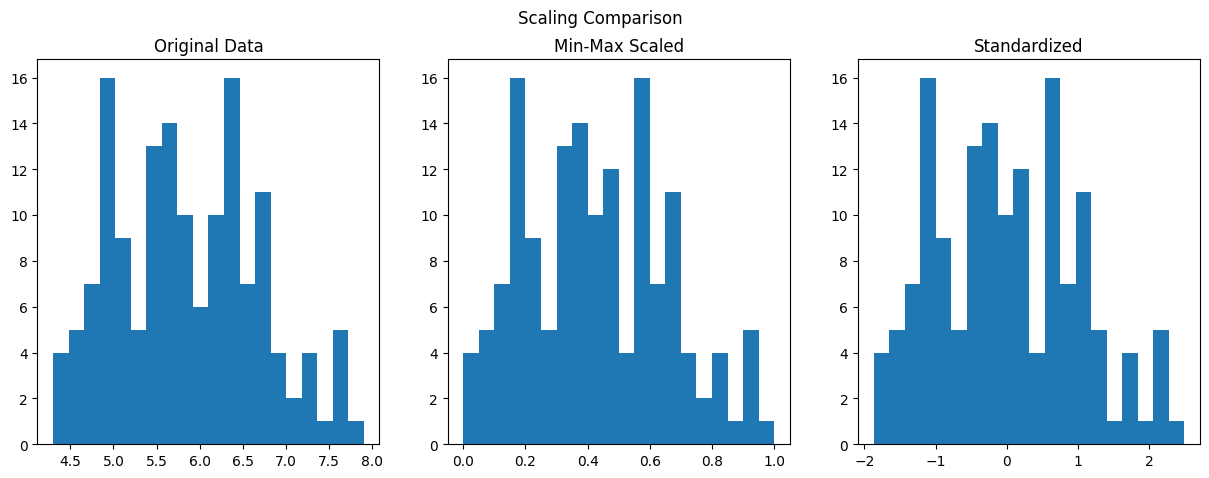

In [16]:
fig, axs = plt.subplots(1,3, figsize=(15,5))

axs[0].hist(original_data, bins=20)
axs[0].set_title("Original Data")

axs[1].hist(minmax_scaler.fit_transform(original_data), bins=20)
axs[1].set_title("Min-Max Scaled")

axs[2].hist(standard_scaler.fit_transform(original_data), bins=20)
axs[2].set_title("Standardized")

fig.suptitle("Scaling Comparison")
plt.show()

Keine Änderung der Distribution, sondern nur Skalierung

#### Einfluss von Outliern auf Skalierung

In [17]:
outlier_data = pd.concat([original_data, pd.DataFrame([20], columns=["SepalLengthCm"])]).reset_index(drop=True)
outlier_data.tail(5)

,SepalLengthCm
146,6.3
147,6.5
148,6.2
149,5.9
150,20.0


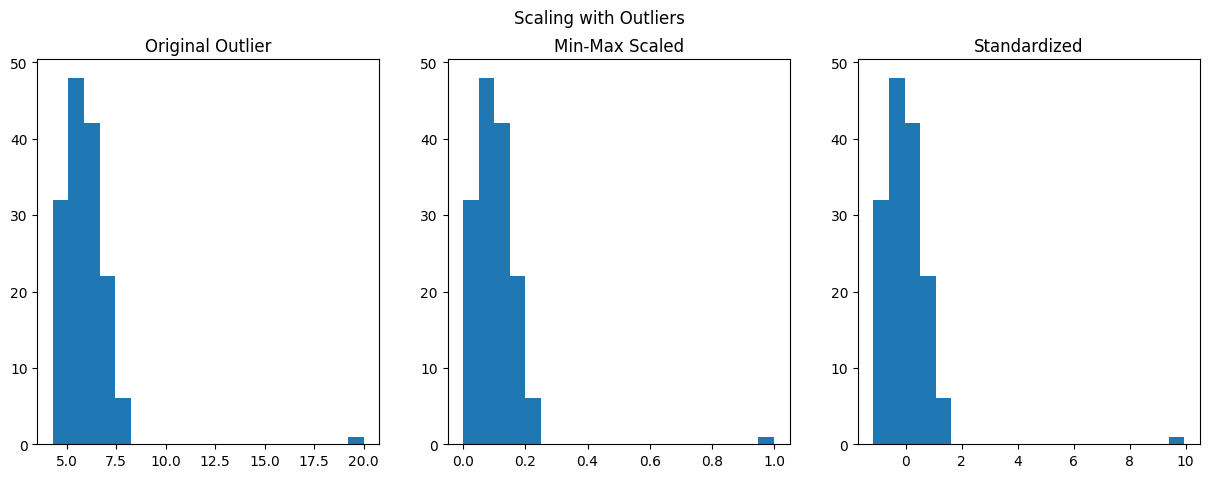

In [18]:
fig, axs = plt.subplots(1,3, figsize=(15,5))

axs[0].hist(outlier_data, bins=20)
axs[0].set_title("Original Outlier")

axs[1].hist(minmax_scaler.fit_transform(outlier_data), bins=20)
axs[1].set_title("Min-Max Scaled")

axs[2].hist(standard_scaler.fit_transform(outlier_data), bins=20)
axs[2].set_title("Standardized")

fig.suptitle("Scaling with Outliers")
plt.show()

### Übungsaufgabe

In [19]:
# Datensatz laden
wine_data = pd.read_csv("wine_quality_data.csv")

# Guten Wein definieren
wine_data["Good Wine"] = wine_data["quality"] >= 7
print("Verhältnis an gutem Wein: ", round(wine_data["Good Wine"].mean()*100, 2), "%")
wine_data

Verhältnis an gutem Wein:  23.4 %


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Good Wine
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,False
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,False
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,False
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,False
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,7.6,0.29,0.49,9.6,0.030,45.0,197.0,0.9938,3.13,0.38,12.3,7,True
1496,6.7,0.62,0.24,1.1,0.039,6.0,62.0,0.9934,3.41,0.32,10.4,5,False
1497,6.8,0.27,0.49,1.2,0.044,35.0,126.0,0.9900,3.13,0.48,12.1,7,True
1498,7.7,0.27,0.49,1.8,0.041,23.0,86.0,0.9914,3.16,0.42,12.5,6,False


In [20]:
# Trainings-, Validierungs-, und Testdaten aufteilen
train_data, test_data = train_test_split(wine_data, test_size=0.3, random_state=0)
val_data, test_data = train_test_split(test_data, test_size=0.5, random_state=0)

# Input und Output Variablen trennen
X_train = train_data.drop(["Good Wine", "quality"], axis=1)
y_train = train_data["Good Wine"]
X_val = val_data.drop(["Good Wine", "quality"], axis=1)
y_val = val_data["Good Wine"]
X_test = test_data.drop(["Good Wine", "quality"], axis=1)
y_test = test_data["Good Wine"]

In [21]:
# Daten standardisieren
standard_scaler = sklearn.preprocessing.StandardScaler()
X_train_scaled = standard_scaler.fit_transform(X_train)
X_val_scaled = standard_scaler.transform(X_val)
X_test_scaled = standard_scaler.transform(X_test)

In [22]:
training_results = {}
validation_results = {}

# Verschiedene KNN Modelle für unterschiedliche Werte von k
for k in range(1,200,3):
    # Modell definieren und trainieren
    knn = sklearn.neighbors.KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    # Modell auf Trainings- und Validierungsgenauigkeit testen
    training_results[k] = knn.score(X_train_scaled, y_train)
    validation_results[k] = (knn.predict(X_val_scaled) == y_val).mean()

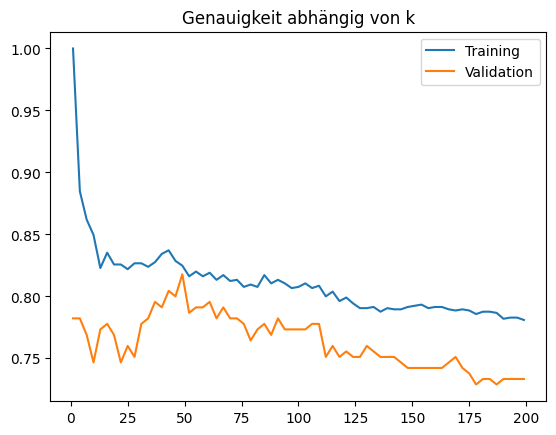

In [23]:
# Ergebnisse des Trainings visuell darstellen
x, y = zip(*training_results.items())
plt.plot(x, y, label="Training")
x, y = zip(*validation_results.items())
plt.plot(x, y, label="Validation")

plt.title("Genauigkeit abhängig von k")
plt.legend()
plt.show()

In [24]:
# Besten Wert von k mit höchster Validierungsgenauigkeit finden
max(validation_results.items(), key=lambda item : item[1])

(49, np.float64(0.8177777777777778))

In [25]:
# Modell mit bestem Wert von k trainieren und Performance auf Testdaten zeigen
knn = sklearn.neighbors.KNeighborsClassifier(n_neighbors=max(validation_results.items(), key=lambda item : item[1])[0])
knn.fit(X_train_scaled, y_train)
print("Accuracy auf Trainingsdaten:", round(knn.score(X_train_scaled, y_train)*100, 2), "%")
print("Accuracy auf Validierungsdaten:", round(knn.score(X_val_scaled, y_val)*100, 2), "%")
print("Accuracy auf Testdaten:", round(knn.score(X_test_scaled, y_test)*100, 2), "%")

Accuracy auf Trainingsdaten: 82.48 %
Accuracy auf Validierungsdaten: 81.78 %
Accuracy auf Testdaten: 83.11 %


In [26]:
pred_test = knn.predict(X_test_scaled)
print("Accuracy auf Testdaten:", round(sklearn.metrics.accuracy_score(y_test, pred_test)*100, 2), "%\n")

print("Recall für Guten Wein auf Testdaten:", round(sklearn.metrics.recall_score(y_test, pred_test, labels=[True])*100, 2), "%")
print("Precision für Guten Wein auf Testdaten:", round(sklearn.metrics.precision_score(y_test, pred_test, labels=[True])*100, 2), "%")
print("F1 Score für Guten Wein auf Testdaten:", round(sklearn.metrics.f1_score(y_test, pred_test, labels=[True])*100, 2), "%")

Accuracy auf Testdaten: 83.11 %

Recall für Guten Wein auf Testdaten: 39.22 %
Precision für Guten Wein auf Testdaten: 74.07 %
F1 Score für Guten Wein auf Testdaten: 51.28 %


In [27]:
training_results = {}
validation_results = {}

# Verschiedene KNN Modelle für unterschiedliche Werte von k
for k in range(1,200,3):
    # Modell definieren und trainieren
    knn = sklearn.neighbors.KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    # Modell auf Trainings- und Validierungsgenauigkeit testen
    training_results[k] = sklearn.metrics.f1_score(knn.predict(X_train_scaled), y_train)
    validation_results[k] = sklearn.metrics.f1_score(knn.predict(X_val_scaled), y_val)
max(validation_results.items(), key=lambda item : item[1])

(1, 0.6259541984732825)

In [28]:
knn = sklearn.neighbors.KNeighborsClassifier(n_neighbors=max(validation_results.items(), key=lambda item : item[1])[0])
knn.fit(X_train_scaled, y_train)

pred_test = knn.predict(X_test_scaled)
print("Accuracy auf Testdaten:", round(sklearn.metrics.accuracy_score(y_test, pred_test)*100, 2), "%\n")

print("Recall für Guten Wein auf Testdaten:", round(sklearn.metrics.recall_score(y_test, pred_test, labels=[True])*100, 2), "%")
print("Precision für Guten Wein auf Testdaten:", round(sklearn.metrics.precision_score(y_test, pred_test, labels=[True])*100, 2), "%")
print("F1 Score für Guten Wein auf Testdaten:", round(sklearn.metrics.f1_score(y_test, pred_test, labels=[True])*100, 2), "%")

Accuracy auf Testdaten: 82.22 %

Recall für Guten Wein auf Testdaten: 58.82 %
Precision für Guten Wein auf Testdaten: 61.22 %
F1 Score für Guten Wein auf Testdaten: 60.0 %


In [29]:
sklearn.metrics.confusion_matrix(y_test, pred_test)

array([[155,  19],
       [ 21,  30]])

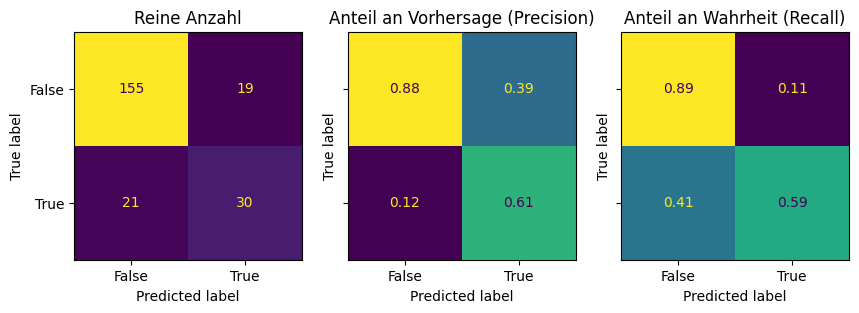

In [30]:
fig, axs = plt.subplots(1,3,figsize=(10,4), sharey=True)
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y_test, pred_test, ax=axs[0], colorbar=False)
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y_test, pred_test, ax=axs[1], normalize="pred", colorbar=False)
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y_test, pred_test, ax=axs[2], normalize="true", colorbar=False)

axs[0].set_title("Reine Anzahl")
axs[1].set_title("Anteil an Vorhersage (Precision)")
axs[2].set_title("Anteil an Wahrheit (Recall)")
plt.show()

### Manuelle Implementierung

In [31]:
def knn_predict(distance_matrix, training_truth, k):
    predictions = []
    
    # Distanz zu allen trainingsdaten für jeden zu evaluierenden Eintrag:
    for distance in distance_matrix:
        distance = list(zip(distance, training_truth))

        # k nächsten Trainingswerte finden
        voting = [e[1] for e in sorted(distance)[:k]]
        if sum(voting) == k/2:
            # Zufall entscheidet falls es unentschieden ist
            predictions.append(random.randint(0,1))
        else:
            # Mehr Wahr oder Falsch gestimmt?
            predictions.append(sum(voting) > k/2)
    return predictions

In [32]:
# Distanz Matrix berechnen
distance_matrix = scipy.spatial.distance.cdist(X_val_scaled, X_train_scaled)
# Vorhersage auf Basis der Distanzmatrix treffen
predictions = knn_predict(distance_matrix, y_train, 49)
#Ergebnis ausgeben
print("Accuracy auf Validierungsdaten:", round(sum(predictions == y_val) / len(predictions) * 100, 2), "%")

distance_matrix = scipy.spatial.distance.cdist(X_test_scaled, X_train_scaled)
predictions = knn_predict(distance_matrix, y_train, 49)
print("Accuracy auf Testdaten:", round(sum(predictions == y_test) / len(predictions) * 100, 2), "%")

Accuracy auf Validierungsdaten: 81.78 %
Accuracy auf Testdaten: 83.11 %


In [33]:
distance_matrix.shape

(225, 1050)

### Verschiedene Werte für k

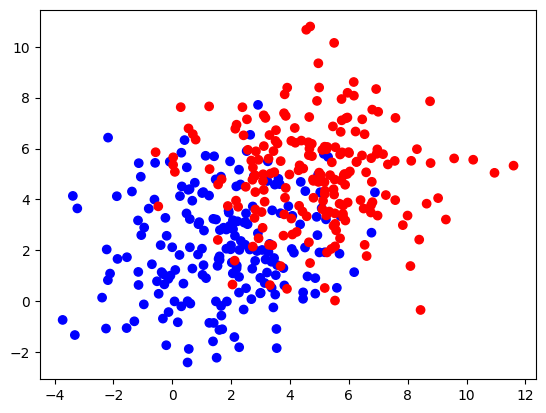

In [34]:
data_1 = np.random.normal(2,2,200), np.random.normal(2,2,200)
data_2 = np.random.normal(5,2,200), np.random.normal(5,2,200)

data_1 = pd.DataFrame(data_1).transpose()
data_1["Class"] = "Blue"
data_2 = pd.DataFrame(data_2).transpose()
data_2["Class"] = "Red"
data = pd.concat([data_1, data_2])

plt.scatter(data[0], data[1], c=data["Class"])
plt.show()

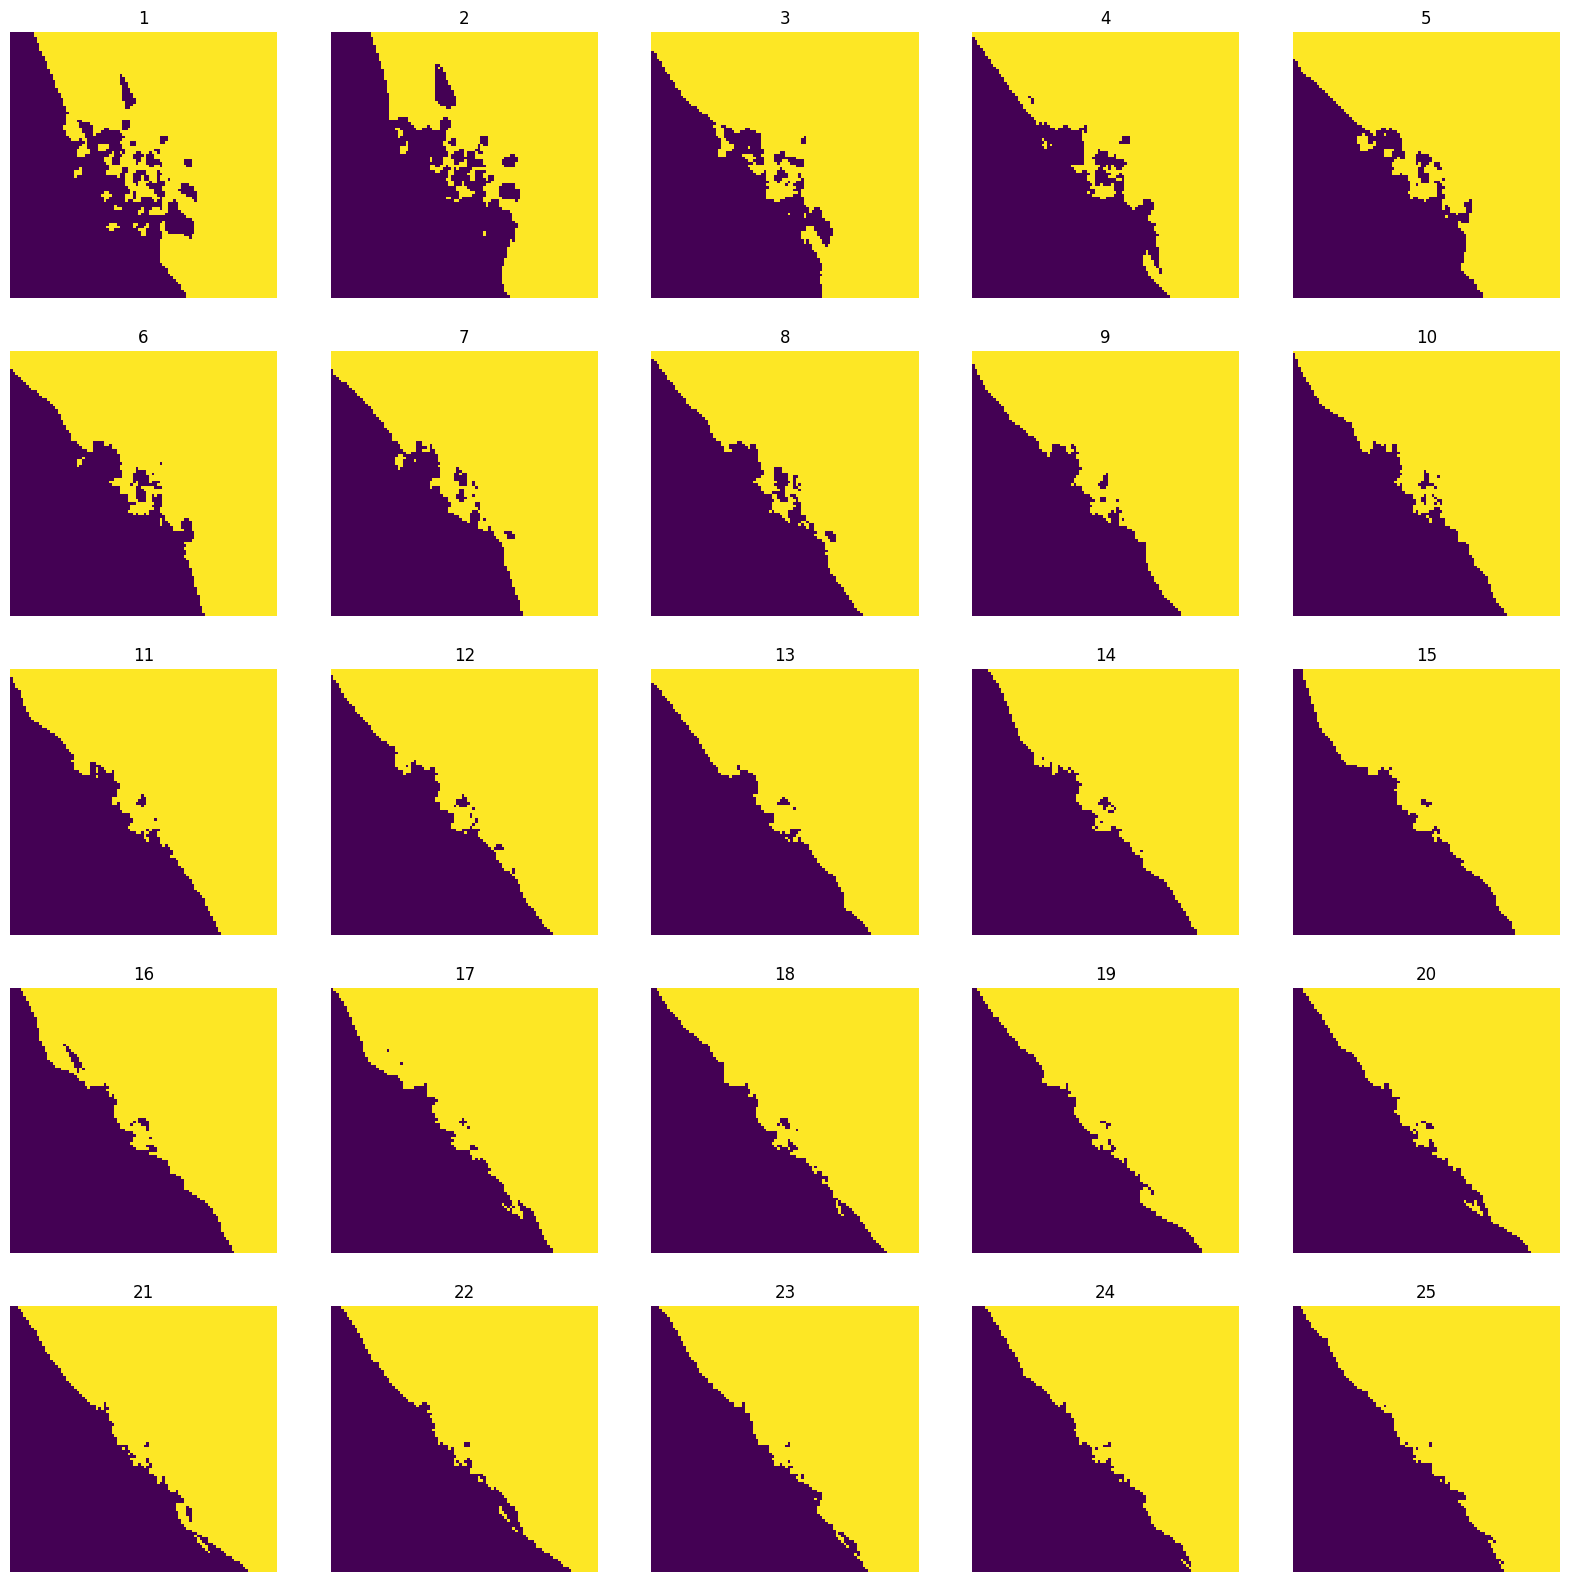

In [35]:
fig, axs = plt.subplots(5,5, figsize=(20,20))
for k in range(0, 25):
    knn = sklearn.neighbors.KNeighborsClassifier(n_neighbors=k+1)
    knn.fit(data[[0,1]], data["Class"])
    sklearn.inspection.DecisionBoundaryDisplay.from_estimator(knn, data[[0,1]], response_method="predict", plot_method="pcolormesh", ax=axs[k//5][k%5])
    axs[k//5][k%5].set_title(k+1)
    axs[k//5][k%5].axis("off")
plt.show()

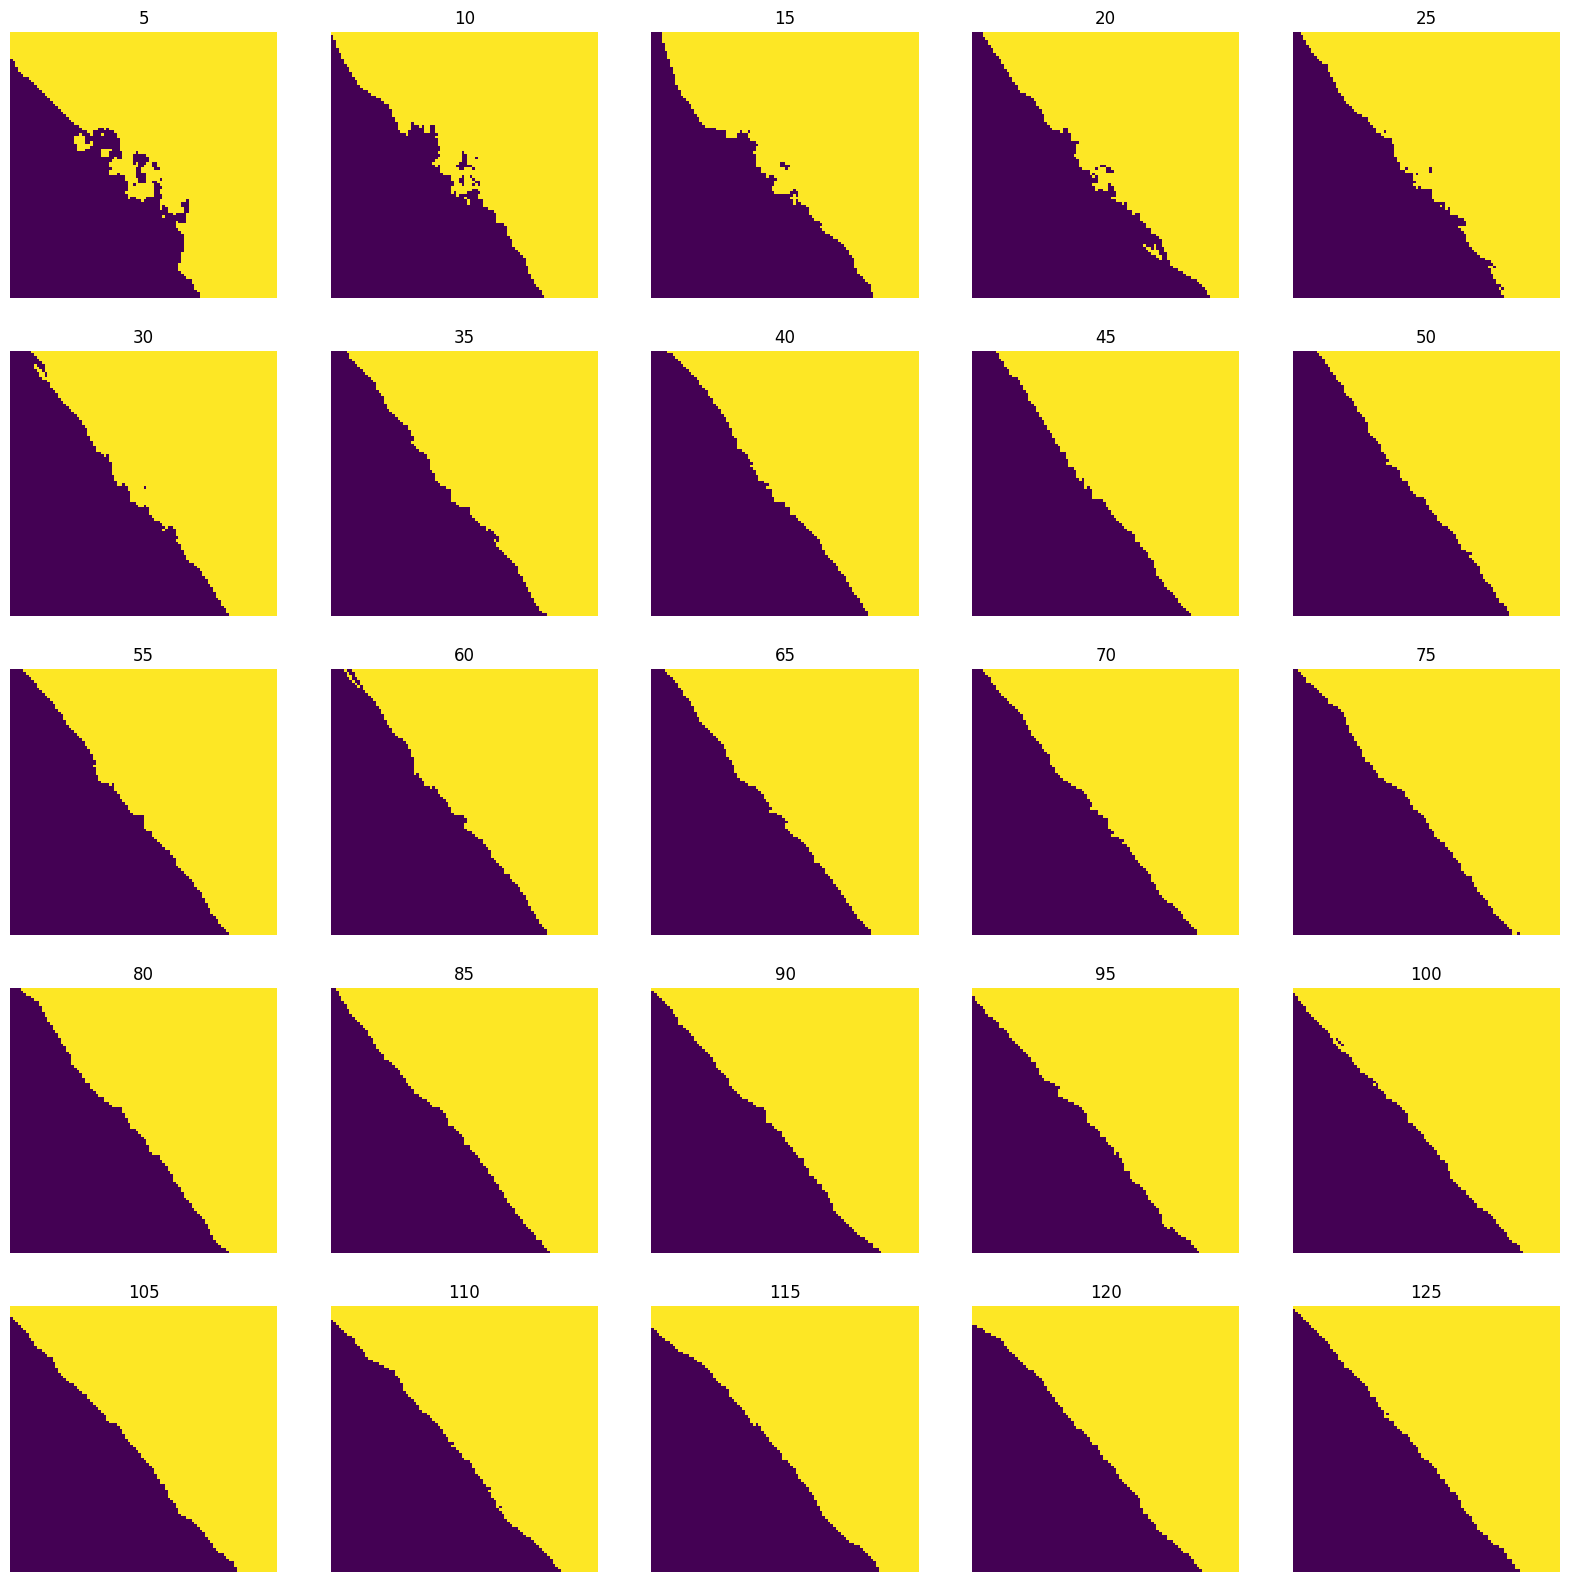

In [36]:
fig, axs = plt.subplots(5,5, figsize=(20,20))
for k in range(0, 25):
    knn = sklearn.neighbors.KNeighborsClassifier(n_neighbors=(k+1)*5)
    knn.fit(data[[0,1]], data["Class"])
    sklearn.inspection.DecisionBoundaryDisplay.from_estimator(knn, data[[0,1]], response_method="predict", plot_method="pcolormesh", ax=axs[k//5][k%5])
    axs[k//5][k%5].set_title((k+1)*5)
    axs[k//5][k%5].axis("off")
plt.show()

### Imbalanced data

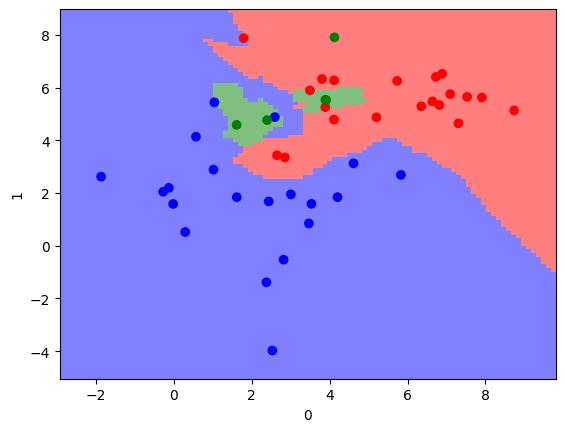

In [37]:
# Generieren eines Datensatz mit fehlender Balance
data_1 = np.random.normal(2,2,20), np.random.normal(2,2,20)
data_2 = np.random.normal(5,2,20), np.random.normal(5,1,20)
data_3 = np.random.normal(2,1.5,5), np.random.normal(4,1.5,5)

data_1 = pd.DataFrame(data_1).transpose()
data_1["Class"] = "Blue"
data_2 = pd.DataFrame(data_2).transpose()
data_2["Class"] = "Red"
data_3 = pd.DataFrame(data_3).transpose()
data_3["Class"] = "Green"
data = pd.concat([data_1, data_2, data_3])


# Trainieren eines knn Klassifizierungsalgorithmus auf diesen Daten
knn = sklearn.neighbors.KNeighborsClassifier(n_neighbors=3)
knn.fit(data[[0,1]], data["Class"])

# Darstellen des Ergebnisses
fig = plt.figure()
ax1 = fig.add_subplot()
sklearn.inspection.DecisionBoundaryDisplay.from_estimator(knn, data[[0,1]],
                                                          response_method="predict",
                                                          plot_method="pcolormesh",
                                                          cmap=matplotlib.colors.ListedColormap(["Blue", "Green", "Red"]),
                                                          alpha=0.5, ax=fig.axes[0])
fig.axes[0] = plt.scatter(data[0], data[1], c=data["Class"])
plt.show()

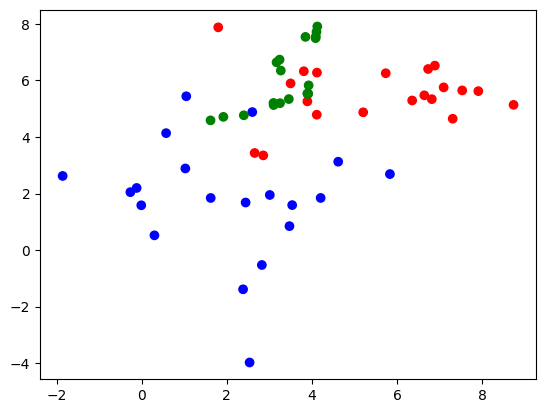

In [38]:
# Anwendung von SMOTE zum Oversampling von der grünen Minderheitsklasse
balanced_data, balanced_class = imblearn.over_sampling.SMOTE(sampling_strategy={"Green":20}, k_neighbors=4).fit_resample(data[[0,1]], data["Class"])
fig.axes[0] = plt.scatter(balanced_data[0], balanced_data[1], c=balanced_class)
plt.show()

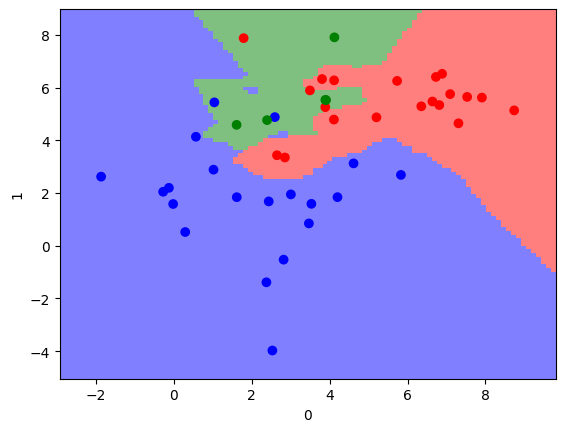

In [39]:
# Darstellen der Ergebnisses eines Klassifikators der auf den oversampled Daten trainiert wurde
knn = sklearn.neighbors.KNeighborsClassifier(n_neighbors=3)
knn.fit(balanced_data, balanced_class)

fig = plt.figure()
ax1 = fig.add_subplot()

sklearn.inspection.DecisionBoundaryDisplay.from_estimator(knn, balanced_data,
                                                          response_method="predict",
                                                          plot_method="pcolormesh",
                                                          cmap=matplotlib.colors.ListedColormap(["Blue", "Green", "Red"]),
                                                          alpha=0.5, ax=fig.axes[0])
fig.axes[0] = plt.scatter(data[0], data[1], c=data["Class"])
plt.show()

#### Anwendung auf das Weinbeispiel

In [40]:
# Sehr Guten Wein definieren
imbalanced_wine_data = wine_data.copy()
imbalanced_wine_data["Very Good Wine"] = imbalanced_wine_data["quality"] > 7
print("Verhältnis an sehr gutem Wein: ", round(imbalanced_wine_data["Very Good Wine"].mean()*100, 2), "%")
imbalanced_wine_data

Verhältnis an sehr gutem Wein:  4.6 %


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Good Wine,Very Good Wine
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,False,False
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,False,False
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,False,False
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,False,False
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,7.6,0.29,0.49,9.6,0.030,45.0,197.0,0.9938,3.13,0.38,12.3,7,True,False
1496,6.7,0.62,0.24,1.1,0.039,6.0,62.0,0.9934,3.41,0.32,10.4,5,False,False
1497,6.8,0.27,0.49,1.2,0.044,35.0,126.0,0.9900,3.13,0.48,12.1,7,True,False
1498,7.7,0.27,0.49,1.8,0.041,23.0,86.0,0.9914,3.16,0.42,12.5,6,False,False


In [41]:
# Trainings-, Validierungs-, und Testdaten aufteilen
train_data, test_data = train_test_split(imbalanced_wine_data, test_size=0.3, random_state=0)
val_data, test_data = train_test_split(test_data, test_size=0.5, random_state=0)

# Input und Output Variablen trennen
X_train = train_data.drop(["Very Good Wine", "Good Wine", "quality"], axis=1)
y_train = train_data["Very Good Wine"]
X_val = val_data.drop(["Very Good Wine", "Good Wine", "quality"], axis=1)
y_val = val_data["Very Good Wine"]
X_test = test_data.drop(["Very Good Wine", "Good Wine", "quality"], axis=1)
y_test = test_data["Very Good Wine"]

# Daten standardisieren
standard_scaler = sklearn.preprocessing.StandardScaler()
X_train_scaled = standard_scaler.fit_transform(X_train)
X_val_scaled = standard_scaler.transform(X_val)
X_test_scaled = standard_scaler.transform(X_test)

Zuerst folgen wir derselben Methodik wie am Anfang, und finden das Modell mit der besten Validierungsgenauigkeit:

In [42]:
training_results = {}
validation_results = {}

# Verschiedene KNN Modelle für unterschiedliche Werte von k
for k in range(1,100,3):
    # Modell definieren und trainieren
    knn = sklearn.neighbors.KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    # Modell auf Trainings- und Validierungsgenauigkeit testen
    training_results[k] = knn.score(X_train_scaled, y_train)
    validation_results[k] = (knn.predict(X_val_scaled) == y_val).mean()

knn = sklearn.neighbors.KNeighborsClassifier(n_neighbors=max(validation_results.items(), key=lambda item : item[1])[0])
knn.fit(X_train_scaled, y_train)
print("Bester Wert für k:", knn.n_neighbors)

pred_test = knn.predict(X_test_scaled)
print("Accuracy auf Testdaten:", round(sklearn.metrics.accuracy_score(y_test, pred_test)*100, 2), "%\n")

print("Recall für Sehr Guten Wein auf Testdaten:", round(sklearn.metrics.recall_score(y_test, pred_test, labels=[True])*100, 2), "%")
print("Precision für Sehr Guten Wein auf Testdaten:", round(sklearn.metrics.precision_score(y_test, pred_test, labels=[True])*100, 2), "%")
print("F1 Score für Sehr Guten Wein auf Testdaten:", round(sklearn.metrics.f1_score(y_test, pred_test, labels=[True])*100, 2), "%")

Bester Wert für k: 4
Accuracy auf Testdaten: 96.0 %

Recall für Sehr Guten Wein auf Testdaten: 0.0 %
Precision für Sehr Guten Wein auf Testdaten: 0.0 %
F1 Score für Sehr Guten Wein auf Testdaten: 0.0 %


Dies hat eindeutig überhaupt nicht geklappt, wählen wir jetzt also das Modell basierend auf dem F1 Score aus:

In [43]:
training_results = {}
validation_results = {}

# Verschiedene KNN Modelle für unterschiedliche Werte von k
for k in range(1,100,3):
    # Modell definieren und trainieren
    knn = sklearn.neighbors.KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    # Modell auf Trainings- und Validierungsgenauigkeit testen
    training_results[k] = sklearn.metrics.f1_score(knn.predict(X_train_scaled), y_train)
    validation_results[k] = sklearn.metrics.f1_score(knn.predict(X_val_scaled), y_val)

knn = sklearn.neighbors.KNeighborsClassifier(n_neighbors=max(validation_results.items(), key=lambda item : item[1])[0])
knn.fit(X_train_scaled, y_train)
print("Bester Wert für k:", knn.n_neighbors)

pred_test = knn.predict(X_test_scaled)
print("Accuracy auf Testdaten:", round(sklearn.metrics.accuracy_score(y_test, pred_test)*100, 2), "%\n")

print("Recall für Sehr Guten Wein auf Testdaten:", round(sklearn.metrics.recall_score(y_test, pred_test, labels=[True])*100, 2), "%")
print("Precision Sehr für Guten Wein auf Testdaten:", round(sklearn.metrics.precision_score(y_test, pred_test, labels=[True])*100, 2), "%")
print("F1 Score für Sehr Guten Wein auf Testdaten:", round(sklearn.metrics.f1_score(y_test, pred_test, labels=[True])*100, 2), "%")

Bester Wert für k: 1
Accuracy auf Testdaten: 93.33 %

Recall für Sehr Guten Wein auf Testdaten: 28.57 %
Precision Sehr für Guten Wein auf Testdaten: 16.67 %
F1 Score für Sehr Guten Wein auf Testdaten: 21.05 %


In [44]:
# Resampling
X_train_resampled, y_train_resampled = imblearn.over_sampling.SMOTE(sampling_strategy=0.6).fit_resample(X_train_scaled, y_train)
print(len(y_train), y_train.mean())
print(len(y_train_resampled), y_train_resampled.mean())

1050 0.04476190476190476
1604 0.37468827930174564


In [45]:
training_results = {}
validation_results = {}

# Verschiedene KNN Modelle für unterschiedliche Werte von k
for k in range(1,100,3):
    # Modell definieren und trainieren
    knn = sklearn.neighbors.KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_resampled, y_train_resampled)

    # Modell auf Validierungsgenauigkeit testen
    validation_results[k] = sklearn.metrics.f1_score(knn.predict(X_val_scaled), y_val)

knn = sklearn.neighbors.KNeighborsClassifier(n_neighbors=max(validation_results.items(), key=lambda item : item[1])[0])
knn.fit(X_train_resampled, y_train_resampled)
print("Bester Wert für k:", knn.n_neighbors)

pred_test = knn.predict(X_test_scaled)
print("Accuracy auf Testdaten:", round(sklearn.metrics.accuracy_score(y_test, pred_test)*100, 2), "%\n")

print("Recall für Sehr Guten Wein auf Testdaten:", round(sklearn.metrics.recall_score(y_test, pred_test, labels=[True])*100, 2), "%")
print("Precision für Sehr Guten Wein auf Testdaten:", round(sklearn.metrics.precision_score(y_test, pred_test, labels=[True])*100, 2), "%")
print("F1 Score für Sehr Guten Wein auf Testdaten:", round(sklearn.metrics.f1_score(y_test, pred_test, labels=[True])*100, 2), "%")

Bester Wert für k: 1
Accuracy auf Testdaten: 88.44 %

Recall für Sehr Guten Wein auf Testdaten: 42.86 %
Precision für Sehr Guten Wein auf Testdaten: 12.0 %
F1 Score für Sehr Guten Wein auf Testdaten: 18.75 %


### Multiclass Klassifikation

In [46]:
iris_data
input_data = iris_data.drop("Species", axis=1)
output_data = iris_data["Species"]
results = {}

knn = sklearn.neighbors.KNeighborsClassifier(30)
knn.fit(input_data, output_data)
print("Bester Wert für k:", knn.n_neighbors)

predictions = knn.predict(input_data)
print("Accuracy ", round(sklearn.metrics.accuracy_score(output_data, predictions)*100, 2), "%")

Bester Wert für k: 30
Accuracy  95.33 %


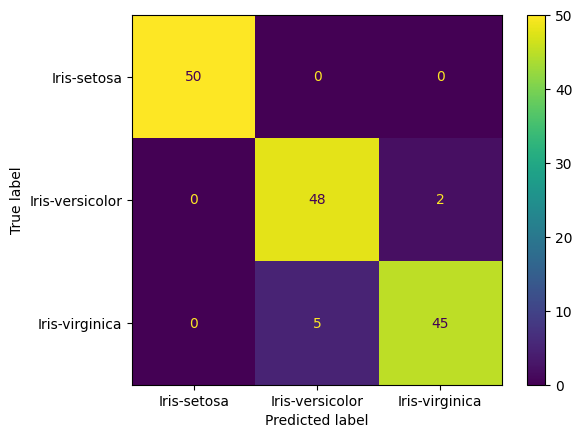

In [47]:
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(output_data, predictions, colorbar=True)
plt.show()

In [48]:
print("Recall für Virginica:", round(sklearn.metrics.recall_score(output_data, predictions, average="micro", labels=["Iris-virginica"])*100, 2), "%")
print("Precision für Virginica:", round(sklearn.metrics.precision_score(output_data, predictions, average="micro", labels=["Iris-virginica"])*100, 2), "%")

Recall für Virginica: 90.0 %
Precision für Virginica: 95.74 %


In [49]:
np.round((45 / (45+5), 45 / (45+2)),4) * 100

array([90.  , 95.74])

In [50]:
print("Recall für Versicolor:", round(sklearn.metrics.recall_score(output_data, predictions, average="micro", labels=["Iris-versicolor"])*100, 2), "%")
48 / (48+2)

Recall für Versicolor: 96.0 %


0.96